<a href="https://colab.research.google.com/github/Delean-Mafra/faculdade/blob/main/atividades_aplicacao_de_ciencia_de_dados_para_negocios/atividade_pratica_7_a_16/atividade_pratica13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática 13 – Segmentação de Clientes.
Nesta atividade, exploraremos técnicas de clusterização para segmentar uma base de dados de clientes utilizando K-Means, DBSCAN e Hierarchical Clustering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Carregar e Preparar os Dados
data = {
    'Idade': [25, 34, 45, 31, 40, 23, 35, 50, 43, 52],
    'Renda Anual (k$)': [15, 25, 35, 45, 50, 55, 60, 70, 80, 90],
    'Pontuação de Gastos (1-100)': [39, 81, 6, 77, 40, 76, 94, 3, 72, 14]
}
df = pd.DataFrame(data)
display(df)

,Idade,Renda Anual (k$),Pontuação de Gastos (1-100)
0,25,15,39
1,34,25,81
2,45,35,6
3,31,45,77
4,40,50,40
5,23,55,76
6,35,60,94
7,50,70,3
8,43,80,72
9,52,90,14


In [ ]:
# 2. Normalização dos Dados
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
print("Dados normalizados prontos para processamento.")

Dados normalizados prontos para processamento.


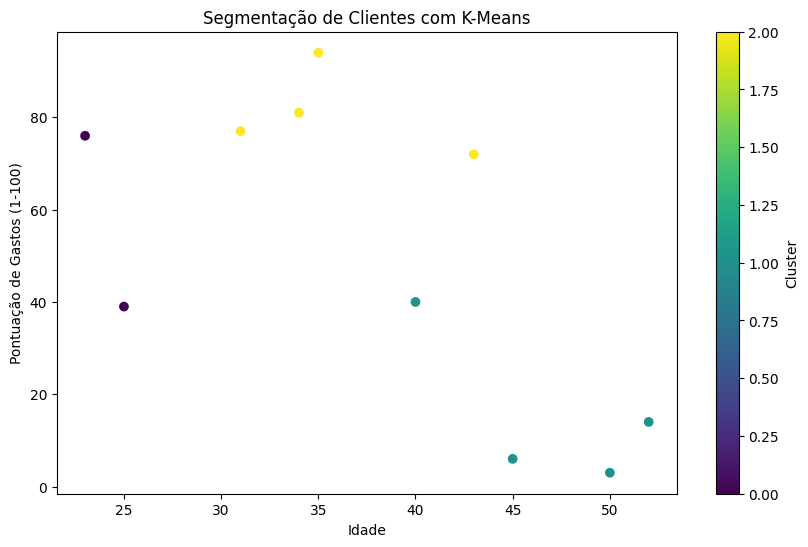

In [ ]:
# 3. Aplicação do Algoritmo K-Means
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
clusters_kmeans = kmeans.fit_predict(scaled_data)
df['Cluster_KMeans'] = clusters_kmeans

plt.figure(figsize=(10, 6))
plt.scatter(df['Idade'], df['Pontuação de Gastos (1-100)'], c=df['Cluster_KMeans'], cmap='viridis')
plt.title('Segmentação de Clientes com K-Means')
plt.xlabel('Idade')
plt.ylabel('Pontuação de Gastos (1-100)')
plt.colorbar(label='Cluster')
plt.show()

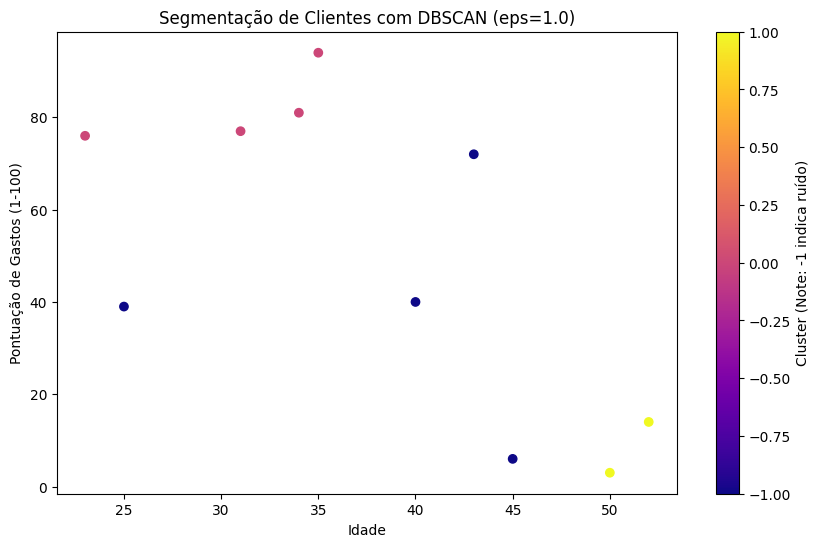

In [7]:
# 4. Aplicação do Algoritmo DBSCAN (Ajustado para eps=1.0)
dbscan = DBSCAN(eps=1.0, min_samples=2)
clusters_dbscan = dbscan.fit_predict(scaled_data)
df['Cluster_DBSCAN'] = clusters_dbscan

plt.figure(figsize=(10, 6))
plt.scatter(df['Idade'], df['Pontuação de Gastos (1-100)'], c=df['Cluster_DBSCAN'], cmap='plasma')
plt.title('Segmentação de Clientes com DBSCAN (eps=1.0)')
plt.xlabel('Idade')
plt.ylabel('Pontuação de Gastos (1-100)')
plt.colorbar(label='Cluster (Note: -1 indica ruído)')
plt.show()

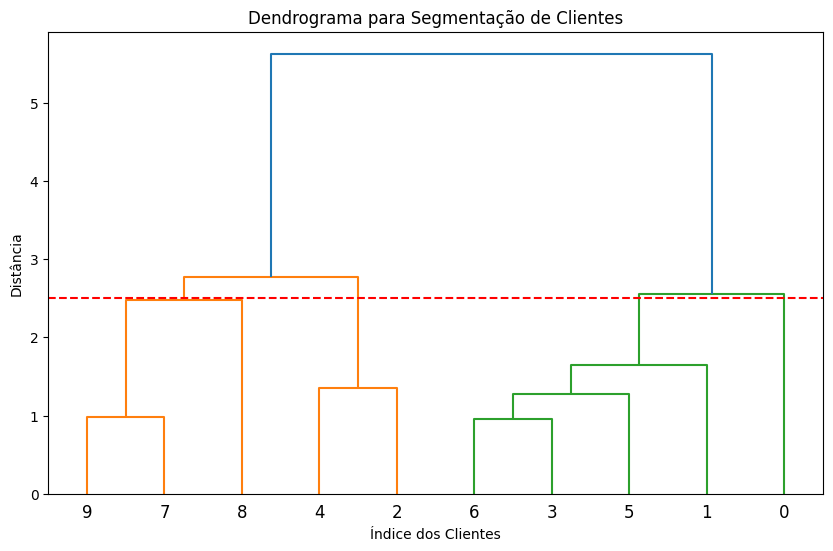

In [8]:
# 5. Aplicação do Hierarchical Clustering com Linha de Corte
linked = linkage(scaled_data, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.axhline(y=2.5, color='r', linestyle='--') # Linha de corte sugerindo 3 clusters
plt.title('Dendrograma para Segmentação de Clientes')
plt.xlabel('Índice dos Clientes')
plt.ylabel('Distância')
plt.show()

In [9]:
import pandas as pd

# 6. Exibir centroides e DataFrame Final com classificações
centroids = kmeans.cluster_centers_
centroids_unscaled = scaler.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_unscaled, columns=['Idade', 'Renda Anual (k$)', 'Pontuação de Gastos (1-100)'])

print("Centroides dos clusters (Médias por Grupo):")
display(centroids_df)

print("\nBase de Dados Finalizada:")
display(df)

Centroides dos clusters (Médias por Grupo):


,Idade,Renda Anual (k$),Pontuação de Gastos (1-100)
0,24.00,35.00,57.50
1,46.75,61.25,15.75
2,35.75,52.50,81.00



Base de Dados Finalizada:


,Idade,Renda Anual (k$),Pontuação de Gastos (1-100),Cluster_KMeans,Cluster_DBSCAN
0,25,15,39,0,-1
1,34,25,81,2,0
2,45,35,6,1,-1
3,31,45,77,2,0
4,40,50,40,1,-1
5,23,55,76,0,0
6,35,60,94,2,0
7,50,70,3,1,1
8,43,80,72,2,-1
9,52,90,14,1,1


# 7. Análise dos Resultados e Discussão

### Comparação dos Algoritmos:
- **K-Means:** Dividiu a base de forma clara em 3 grupos. É ideal quando já temos uma ideia do número de segmentos desejados. Pelos centroides, podemos notar perfis como 'Jovens com alto gasto' ou 'Idosos com baixo gasto'.
- **DBSCAN:** Identificou muitos pontos como ruído (`-1`) com os parâmetros padrão. Isso mostra que os dados estão muito dispersos para a densidade exigida (`eps=0.5`), sugerindo que para esta base pequena, o K-Means ou Hierárquico são mais intuitivos.
- **Hierarchical Clustering:** O dendrograma revelou que a maior distância de fusão ocorre entre os índices iniciais, validando que 3 clusters é uma escolha razoável para simplificação do negócio.

### Sugestão de Estratégia:
Com base nos perfis, a empresa pode:
1. Criar campanhas de fidelidade para o grupo de alto gasto.
2. Desenvolver produtos de entrada para o grupo de menor renda/gasto.
3. Personalizar a comunicação por faixa etária conforme identificado nos clusters.

# 8. Conclusão

A atividade demonstrou como diferentes algoritmos de clusterização podem ser aplicados para segmentar clientes com base em idade, renda e pontuação de gastos. O K-Means mostrou-se eficiente para identificar grupos pré-definidos, o DBSCAN evidenciou a sensibilidade a parâmetros de densidade e o Hierarchical Clustering forneceu uma visão hierárquica útil para decidir o número de clusters. A análise dos centroides e dos perfis resultantes permite transformar dados em insights estratégicos, apoiando decisões de marketing, fidelização e personalização de serviços. Assim, a segmentação de clientes se confirma como uma ferramenta essencial para aumentar competitividade e satisfação no ambiente de negócios.
